## Setup

In [2]:
import json

#get params
with open("./params.json", mode = "r", encoding = "utf-8") as f:
    data = json.load(f)
    seed_vals = data["seed_vals"]
    ensemble_root_path = data["ensemble_root_path"]
    dataset_path_test_stream_windowed = data["dataset_path"]["test"]["stream"]["windowed"]
    dataset_path_test_stream_full = data["dataset_path"]["test"]["stream"]["full"]
    dataset_path_test_reversal_windowed = data["dataset_path"]["test"]["reversal"]["windowed"]
    dataset_path_test_reversal_full = data["dataset_path"]["test"]["reversal"]["full"]
    stats_path = data["stats_path"]
    num_single_sample_timesteps = data["num_single_sample_timesteps"]
    input_window_length = data["input_window_length"]
    label_window_length = data["label_window_length"]
    valid_length = input_window_length + label_window_length
    input_features = data["input_features"]
    label_features = data["label_features"]
    extra_features = data["extra_features"]
    num_label_features = len(label_features)
    window_stride = data["window_stride"]
    num_datapoints_per_timeseries = len(
        list(
            range(
                0, num_single_sample_timesteps - (input_window_length + label_window_length) + 1, window_stride
            )
        )
    )
    # num_datapoints_per_timeseries = 1 + (num_single_sample_timesteps - (input_window_length + label_window_length) + 1) // window_stride

    seed_val = 0

    # Use for kdeplot inference
    batch_size = data["batch_size"]

In [3]:
import torch
import random
import numpy as np
import pandas as pd
from scipy import stats as stats_module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed_val)
random.seed(seed_val)
np.random.seed(seed_val)

In [4]:
# from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import ipywidgets as widgets
import polars as pl

from utils.pipeline.Model import TimeSeriesHuggingFaceTransformer
# from utils.pipeline.Data import get_mean_std_respected_temporal, WindowedIterableDataset, read_stats
from utils.pipeline.Data import InferenceAnalysisDataset, WindowedDataset
from utils.pipeline.Run import forward_pass

In [5]:
# stats = pl.read_csv(stats_path)

# df_test = InferenceAnalysisDataset(
#     windowed_dataset_path = dataset_path_test_windowed,
#     full_dataset_path = dataset_path_test_full,
#     index_full_update_len = num_datapoints_per_timeseries
# )

### REVERSALS ###

stats = pl.read_csv(stats_path)

df_test = InferenceAnalysisDataset(
    windowed_dataset_path = dataset_path_test_reversal_windowed,
    full_dataset_path = dataset_path_test_reversal_full,
    index_full_update_len = num_datapoints_per_timeseries
)

In [6]:
### Global Params
num_timeseries = 803
first_window = 69

## Computations

In [6]:
model_paths = [
    f"{ensemble_root_path}/22/T5-{input_window_length}-{label_window_length}-{window_stride}-{val}.pt" for val in seed_vals
]

### Reversal Probabilities

In [ ]:
chunk_size = 128

original_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

good_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)


# ---- 1. Build all (timeseries, window) index pairs up front ----
num_windows = 80 - first_window
i_grid, j_grid = np.meshgrid(
    np.arange(num_timeseries), np.arange(first_window, 80), indexing="ij"
)
i_flat = i_grid.flatten()          # shape (N,)
j_flat = j_grid.flatten()          # shape (N,)
data_indices = i_flat * num_datapoints_per_timeseries + j_flat  # shape (N,)
N = data_indices.shape[0]

# ---- 2. Batch-fetch data in one shot instead of one index at a time ----
# zarr supports fancy indexing with an array of indices along axis 0
windows_x = np.asarray(df_test.inputs_windowed[data_indices])       # (N, in_len, feat)
windows_y = np.asarray(df_test.labels_windowed[data_indices])       # (N, out_len, feat)

index_full = data_indices // df_test.index_full_update_len
labels_full_batch = np.asarray(df_test.labels_full[index_full])
extras_full_batch = np.asarray(df_test.extras_full[index_full])

batch_x = torch.from_numpy(windows_x).float().to(device)   # (N, in_len, feat)
batch_y = torch.from_numpy(windows_y).float().to(device)   # (N, out_len, feat)
x_labels = torch.from_numpy(labels_full_batch).float()
extra_full = torch.from_numpy(extras_full_batch).float()

# ---- 3. Load each model exactly once, run one batched forward pass ----
all_preds = torch.zeros((len(model_paths), N) + batch_y.shape[1:])
all_attns = torch.zeros((len(model_paths), N, label_window_length, input_window_length))
losses = np.zeros((len(model_paths), N))

criterion = torch.nn.L1Loss(reduction="none")

for model_idx, path in enumerate(model_paths):
    model = torch.load(path, map_location=device, weights_only=False).to(device)
    model.eval()

    with torch.no_grad():
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)

            outputs = forward_pass(
                model=model,
                batch_x=batch_x[start:end],
                device=device,
                extract_attention=True
            )
            preds = outputs.logits  # (chunk, out_len, feat)

            per_sample_loss = criterion(preds, batch_y[start:end]).mean(dim=(1, 2))  # (chunk,)

            all_preds[model_idx, start:end] = preds.cpu()
            #all_attns[model_idx, start:end] = model.get_average_attention_values()  # will be silently wrong if uncommented
            losses[model_idx, start:end] = per_sample_loss.cpu().numpy()

    del model
    torch.cuda.empty_cache()

# ---- 4. Reshape back to (timeseries, window, ...) if you need that structure later ----
# all_preds = all_preds.view((len(model_paths), num_timeseries, num_windows) + batch_y.shape[1:])
# losses = losses.reshape((len(model_paths), num_timeseries, num_windows))


u_idx = label_features.index("u_list")

# all_preds: (num_models, N, out_len, feat)  |  losses: (num_models, N)
num_models = len(model_paths)

first_timesteps = all_preds[:, :, 0, u_idx]     # (num_models, N)
last_timesteps  = all_preds[:, :, -1, u_idx]    # (num_models, N)

# --- reversal counts, vectorized over models (dim=0) for every sample at once ---
count_pred_reversal_original = (torch.sign(first_timesteps) != torch.sign(last_timesteps)).sum(dim=0).numpy()                                       # (N,)
count_pred_reversal = (last_timesteps.numpy() < 0).sum(axis=0)
count_pred_good_reversal = ((last_timesteps.numpy() < 0) & (losses < 1)).sum(axis=0)     

original_reversal_prob = (count_pred_reversal_original / num_models) * 100 
reversal_prob          = (count_pred_reversal          / num_models) * 100 
good_reversal_prob     = (count_pred_good_reversal      / num_models) * 100

# --- reshape flat (N,) back to (num_timeseries, num_windows) and drop straight into the DataFrames ---
original_reversal_probs.iloc[:, :] = original_reversal_prob.reshape(num_timeseries, num_windows)
reversal_probs.iloc[:, :]          = reversal_prob.reshape(num_timeseries, num_windows)
good_reversal_probs.iloc[:, :]     = good_reversal_prob.reshape(num_timeseries, num_windows)

In [ ]:
original_reversal_probs.to_csv('./analysis/reversal_probs/original_reversal_probs.csv', index=False)
reversal_probs.to_csv('./analysis/reversal_probs/reversal_probs.csv', index=False)
good_reversal_probs.to_csv('./analysis/reversal_probs/good_reversal_probs.csv', index=False)

### Feature Sorting by Reversal Probabilities

In [ ]:
features_100 = []
features_high = []
features_mid = []
features_low = []
features_0 = []

for window_idx in (reversal_probs.columns):
    selected_window_idx = int(window_idx)
    temp_100 = []
    temp_high = []
    temp_mid = []
    temp_low = []
    temp_0 = []

    for i in range(num_timeseries):
        target_timeseries_idx = i
        data_idx = target_timeseries_idx * num_datapoints_per_timeseries + selected_window_idx
        window_x, window_y, x_labels, extra_full = df_test[data_idx]

        reversal_prob = reversal_probs[window_idx][target_timeseries_idx]
        if(reversal_prob == 100):
            temp_100.append(window_x)
        if(reversal_prob >= 80):
            temp_high.append(window_x)
        if((reversal_prob < 80) & (reversal_prob > 20)):
            temp_mid.append(window_x)
        if(reversal_prob <= 20):
            temp_low.append(window_x)
        if(reversal_prob == 0):
            temp_0.append(window_x)

    features_100.append(torch.stack(temp_100) if temp_100 else torch.empty(0))
    features_high.append(torch.stack(temp_high) if temp_high else torch.empty(0))
    features_mid.append(torch.stack(temp_mid) if temp_mid else torch.empty(0))
    features_low.append(torch.stack(temp_low) if temp_low else torch.empty(0))
    features_0.append(torch.stack(temp_0) if temp_0 else torch.empty(0))


In [10]:
torch.save(features_100, './analysis/features_sorted_by_reversal_probs/features_100.pt')
torch.save(features_high, './analysis/features_sorted_by_reversal_probs/features_high.pt')
torch.save(features_mid, './analysis/features_sorted_by_reversal_probs/features_mid.pt')
torch.save(features_low, './analysis/features_sorted_by_reversal_probs/features_low.pt')
torch.save(features_0, './analysis/features_sorted_by_reversal_probs/features_0.pt')

## Analysis

In [7]:
original_reversal_probs = pd.read_csv('./analysis/reversal_probs/original_reversal_probs.csv')
reversal_probs = pd.read_csv('./analysis/reversal_probs/reversal_probs.csv')
good_reversal_probs = pd.read_csv('./analysis/reversal_probs/good_reversal_probs.csv')

features_100 = torch.load('./analysis/features_sorted_by_reversal_probs/features_100.pt')
features_high = torch.load('./analysis/features_sorted_by_reversal_probs/features_high.pt')
features_mid = torch.load('./analysis/features_sorted_by_reversal_probs/features_mid.pt')
features_low = torch.load('./analysis/features_sorted_by_reversal_probs/features_low.pt')
features_0 = torch.load('./analysis/features_sorted_by_reversal_probs/features_0.pt')

In [44]:
colors = ['#00b7ff', '#d4e000', '#d20b64', '#0037FA', '#7A0000']
feature_list = ["b_e", "b_plus", "U"]

### Prediction Horizon

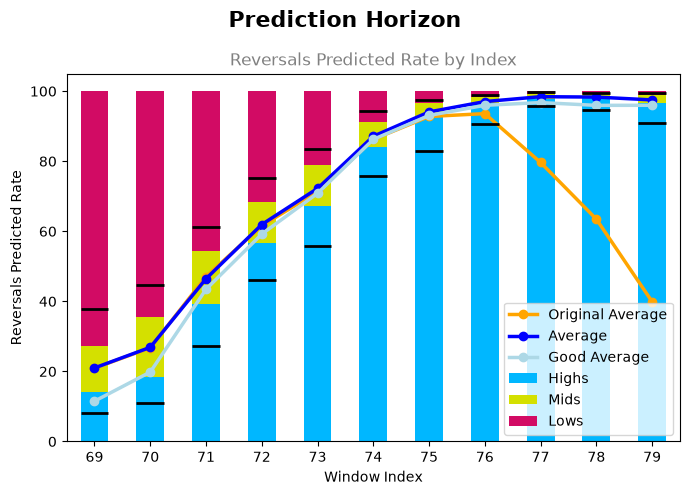

In [9]:
num_windows = 80 - first_window

counts_100 = (reversal_probs == 100).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
counts_high = (reversal_probs >= 80).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
counts_low = (reversal_probs <= 20).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
counts_0 = (reversal_probs == 0).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
counts_mid = (np.full(num_windows, 100) - counts_high - counts_low)

original_averages = original_reversal_probs.mean().to_numpy()
column_averages = reversal_probs.mean().to_numpy()
good_averages = good_reversal_probs.mean().to_numpy()

tick_100_y = counts_100
tick_0_y = 100 - counts_0

data = {
    'Index': reversal_probs.columns,
    'Highs': counts_high,
    'Mids': counts_mid,
    'Lows': counts_low
}
df = pd.DataFrame(data).set_index('Index')

fig, ax = plt.subplots(figsize=(7, 5))
df.plot(kind='bar', stacked=True, ax=ax, width=0.5, color = colors)

bar_width = 0.5
xticks = ax.get_xticks()
ax.hlines(tick_100_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)
ax.hlines(tick_0_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)

ax.plot(ax.get_xticks(), original_averages, color='orange', marker='o', linewidth=2.5, label='Original Average')
ax.plot(ax.get_xticks(), column_averages, color='blue', marker='o', linewidth=2.5, label='Average')
ax.plot(ax.get_xticks(), good_averages, color='lightblue', marker='o', linewidth=2.5, label='Good Average')

ax.legend(loc='lower right')

plt.suptitle('Prediction Horizon', fontsize=16, fontweight='bold')
plt.title('Reversals Predicted Rate by Index', fontsize=12, color='gray')
plt.xlabel('Window Index')
plt.ylabel('Reversals Predicted Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Histogram of Features by Reversal Probability

In [50]:

#### Define Functi0n####
def hist_of_features_by_reversal_prob(
        window_idx,
        feature_name,
        window_subset
    ):

    feature_num = feature_list.index(feature_name)
    window_subset_start, window_subset_end = window_subset

    fig, ax = plt.subplots(figsize = (7, 5))

    #features_100_1 = features_100[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num].mean(axis = 1)
    features_high_1 = features_high[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num].mean(axis = 1)
    features_mid_1 = features_mid[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num].mean(axis = 1)
    features_low_1 = features_low[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num].mean(axis = 1)
    #features_0_1 = features_0[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num].mean(axis = 1)

    t_stat, p_value = stats_module.ttest_ind(features_high_1, features_low_1, equal_var=False)

    bins = bins_list[feature_num]

    #plt.hist(features_100_1, bins, alpha=0.5, histtype='step', color = colors[3], label='100')
    plt.hist(features_high_1, bins, alpha=0.5, histtype='step', color = colors[0], label='High')
    plt.hist(features_mid_1, bins, alpha=0.5, histtype='step', color = colors[1], label='Mid')
    plt.hist(features_low_1, bins, alpha=0.5, histtype='step', color = colors[2], label='Low')
    #plt.hist(features_0_1, bins, alpha=0.5, histtype='step', color = colors[4], label='0')

    plt.axvline(x=features_high_1.mean(), color=colors[0], linestyle='-', linewidth=1)
    plt.axvline(x=features_mid_1.mean(), color=colors[1], linestyle='-', linewidth=1)
    plt.axvline(x=features_low_1.mean(), color=colors[2], linestyle='-', linewidth=1)

    plt.text(0.78, 0.69, s=f"p-value = {p_value:.4f}", transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.5))

    plt.suptitle(f'Histogram of Mean of {feature_name} by Reversal Probability', fontsize=16, fontweight='bold')
    plt.title(f'Window Index: {window_idx}', fontsize=12, color='gray')
    plt.xlabel('Z-Score')
    plt.ylabel('Count')
    plt.legend(title="Reversal Probability", loc='upper right')
    plt.show()

#### Interface #### 
window_idx = widgets.IntSlider(
    value = 72,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
feature_name = widgets.Dropdown(
    options = feature_list,
    value = "U",
    description = "Feature",
    style = {"description_width": "100px"}
)
window_subset = widgets.IntRangeSlider(
    value=[85, 100],   
    min=0,
    max=100,
    step=1,
    description="Window Subset",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "100px"}
)


bins_list = [np.linspace(-4, 4, 40), np.linspace(-4, 4, 20), np.linspace(-0.2, 2.5, 30)]
horizontal = widgets.HBox([feature_name])
ui = widgets.VBox([window_idx, window_subset])

#### Display ####
out = widgets.interactive_output(
    hist_of_features_by_reversal_prob,
    {
        "window_idx": window_idx,
        "feature_name": feature_name,
        "window_subset": window_subset
    }
)
display(horizontal, ui, out)


Output()

### Time-Series Plot of Features by Reversal Probability

In [51]:

def bootstrap_ci(data, axis=0, confidence=0.95, n_boot=2000, seed=None):

    data = np.asarray(data) 

    rng = np.random.default_rng(seed)
    n = data.shape[axis]
    
    out_shape = (n_boot,) + tuple(s for i, s in enumerate(data.shape) if i != axis)
    boot_means = np.empty(out_shape)
    
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = np.take(data, idx, axis=axis)
        boot_means[i] = np.mean(sample, axis=axis)
    
    lower = np.percentile(boot_means, (1 - confidence) / 2 * 100, axis=0)
    upper = np.percentile(boot_means, (1 + confidence) / 2 * 100, axis=0)
    mean = np.mean(data, axis=axis)
    return lower, upper

#### Define Functi0n####
def hist_of_features_by_reversal_prob(
        window_idx,
        feature_name
    ):

    feature_num = feature_list.index(feature_name)

    fig, ax = plt.subplots(figsize = (7, 5))
    ylims = [(-4, 4), (-4, 4), (-1, 3)]

    features_100_2 = features_100[window_idx - first_window][:, :, feature_num].mean(axis = 0)
    features_high_2 = features_high[window_idx - first_window][:, :, feature_num].mean(axis = 0)
    features_mid_2 = features_mid[window_idx - first_window][:, :, feature_num].mean(axis = 0)
    features_low_2 = features_low[window_idx - first_window][:, :, feature_num].mean(axis = 0)
    features_0_2 = features_0[window_idx - first_window][:, :, feature_num].mean(axis = 0)

    _100_ci_lower, _100_ci_upper = bootstrap_ci(features_100[window_idx - first_window][:, :, feature_num])
    high_ci_lower, high_ci_upper = bootstrap_ci(features_high[window_idx - first_window][:, :, feature_num])
    mid_ci_lower, mid_ci_upper = bootstrap_ci(features_mid[window_idx - first_window][:, :, feature_num])
    low_ci_lower, low_ci_upper = bootstrap_ci(features_low[window_idx - first_window][:, :, feature_num])
    _0_ci_lower, _0_ci_upper = bootstrap_ci(features_0[window_idx - first_window][:, :, feature_num])


    #plt.plot(np.arange(0, 100), features_100_2, linestyle='-', marker='o', color=colors[3], label='100')
    #ax.fill_between(x = np.arange(0, 100), y1 = _100_ci_lower, y2 = _100_ci_upper, color = colors[3], alpha = 0.25)

    plt.plot(np.arange(0, 100), features_high_2, linestyle='-', marker='o', color=colors[0], label='High')
    ax.fill_between(x = np.arange(0, 100), y1 = high_ci_lower, y2 = high_ci_upper, color = colors[0], alpha = 0.25)

    plt.plot(np.arange(0, 100), features_mid_2, linestyle='-', marker='o', color=colors[1], label='Mid')
    ax.fill_between(x = np.arange(0, 100), y1 = mid_ci_lower, y2 = mid_ci_upper, color = colors[1], alpha = 0.25)
    
    plt.plot(np.arange(0, 100), features_low_2, linestyle='-', marker='o', color=colors[2], label='Low')
    ax.fill_between(x = np.arange(0, 100), y1 = low_ci_lower, y2 = low_ci_upper, color = colors[2], alpha = 0.25)

    #plt.plot(np.arange(0, 100), features_0_2, linestyle='-', marker='o', color=colors[4], label='0')
    #ax.fill_between(x = np.arange(0, 100), y1 = _0_ci_lower, y2 = _0_ci_upper, color = colors[4], alpha = 0.25)

    plt.ylim(ylims[feature_num])

    plt.suptitle(f'Time-series Plot of {feature_name}', fontsize=16, fontweight='bold')
    plt.title(f'Window Index: {window_idx}', fontsize=12, color='gray')
    plt.xlabel('Index')
    plt.ylabel('Z-Score')
    plt.legend(title="Reversal Probability", loc='upper right')
    plt.show()

#### Interface #### 
window_idx = widgets.IntSlider(
    value = 69,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
feature_name = widgets.Dropdown(
    options = feature_list,
    value = "U",
    description = "Feature",
    style = {"description_width": "100px"}
)


bins_list = [np.linspace(-4, 4, 40), np.linspace(-4, 4, 20), np.linspace(-0.2, 2.5, 30)]
horizontal = widgets.HBox([feature_name])
ui = widgets.VBox([window_idx])

#### Display ####
out = widgets.interactive_output(
    hist_of_features_by_reversal_prob,
    {
        "window_idx": window_idx,
        "feature_name": feature_name
    }
)
display(horizontal, ui, out)



Output()